# ARTI 403 – Image Processing
## Lab 2: Digital Image Fundamentals 

**Name:** Abdulsamad Tuhaysha

**ID:** 2240001093



In [ ]:
# Step 1: Import the libraries we need
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Step 2: Define the helper functions given in the manual

def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    (i.e. we shrink the image, which throws away pixels -> lowers spatial resolution)

    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.

    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    # Using NEAREST interpolation on purpose here (not bilinear/cubic) so we can
    sampled_image = cv2.resize(image, (width // factor, height // factor),
                                interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    (this is the "quantization" step -> fewer brightness levels = more banding)

    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.

    Returns:
        numpy array: Quantized image.
    """
    # 256 // levels = size of each "bucket" of gray values
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side
    so we can visually compare the effect of each operation.
    """
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()


[ WARN:0@3.291] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 52545 (0xcd41) encountered


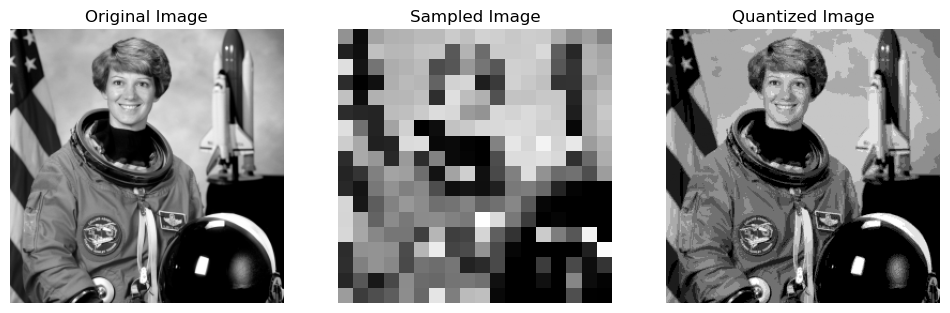

In [3]:
# Step 3: Load the image and set the parameters given in the manual
image_path = '../images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale (IMREAD_GRAYSCALE forces single-channel 8-bit)
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)


### Task #1 — Change the sampling and quantization parameters and observe the effects

I tried a few different combinations below to see what happens at the extremes:
- a **mild** setting (small factor / many levels) -> should look almost identical to the original
- an **aggressive** setting (large factor / few levels) -> should look blocky / posterized


Mild -> sampling factor=2, quantization levels=64


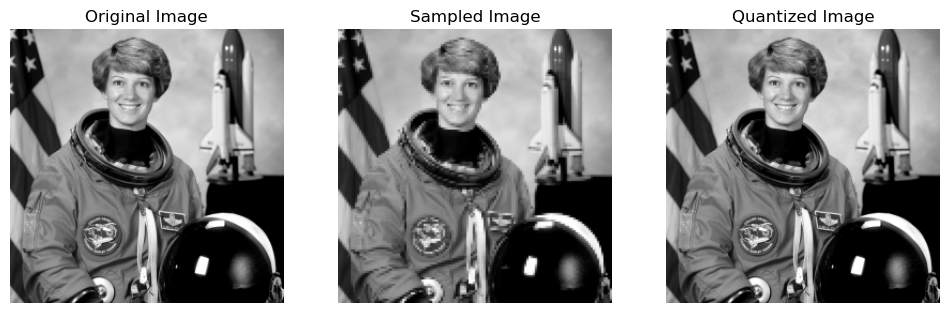

In [4]:
# --- Mild settings: barely visible change ---
mild_factor = 2
mild_levels = 64

sampled_mild = sample_image(original_image, mild_factor)
quantized_mild = quantize_image(original_image, mild_levels)

print(f"Mild -> sampling factor={mild_factor}, quantization levels={mild_levels}")
plot_images(original_image, sampled_mild, quantized_mild)


Aggressive -> sampling factor=32, quantization levels=2


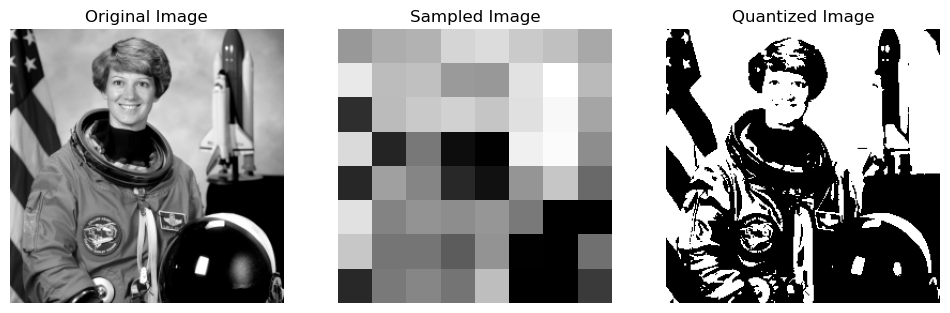

In [5]:
# --- Aggressive settings: heavy pixelation + heavy posterization ---
aggressive_factor = 32
aggressive_levels = 2   # 2 levels = basically black & white (like thresholding)

sampled_aggr = sample_image(original_image, aggressive_factor)
quantized_aggr = quantize_image(original_image, aggressive_levels)

print(f"Aggressive -> sampling factor={aggressive_factor}, quantization levels={aggressive_levels}")
plot_images(original_image, sampled_aggr, quantized_aggr)


## Part 2 — Arithmetic Operations

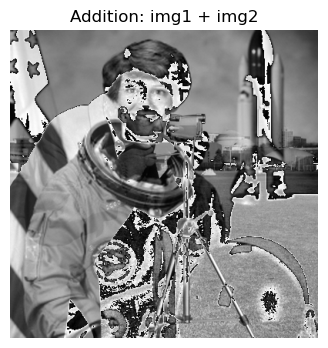

In [6]:
# Reading images with PIL this time (used for the arithmetic/logic sections)
from PIL import Image

img1 = Image.open('../images/lena_gray_256.tif')
img2 = Image.open('../images/cameraman.tif')

# Both images need to be the SAME size before we can add their arrays together
resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

# Simple pixel-wise addition of the two images
addition = im1arr + im2arr
resultImage = Image.fromarray(addition)

# .show() opens a separate viewer window which doesn't render in a notebook,
# so I also display it inline with matplotlib to actually see the result here
resultImage.show()

plt.figure(figsize=(4, 4))
plt.imshow(resultImage, cmap='gray')
plt.title('Addition: img1 + img2')
plt.axis('off')
plt.show()


## Part 3 — Sets and Logical Operations

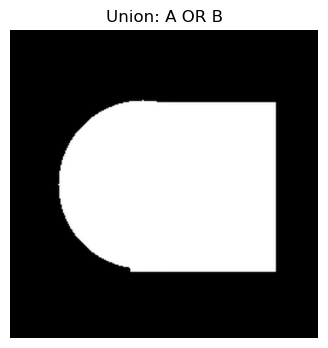

In [7]:
img3 = Image.open('../images/A.png')
img3.show()

img4 = Image.open('../images/B.png')
img4.show()

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

# Bitwise OR between the two arrays = set UNION of the "on" pixels in each image
union = im4arr | im3arr
resultImage2 = Image.fromarray(union)
resultImage2.show()

plt.figure(figsize=(4, 4))
plt.imshow(resultImage2, cmap='gray')
plt.title('Union: A OR B')
plt.axis('off')
plt.show()


## Task #2 — Image arithmetic & set operations on two images

Reusing `im1arr`/`im2arr` (lena/cameraman, both resized to 400x400, grayscale) for the
arithmetic parts, and `im3arr`/`im4arr` (A/B masks) for the set-operation parts, since
the manual asks for these on "two images" / "two grayscale images" respectively.


### 2.1 — Subtract two images and display the result

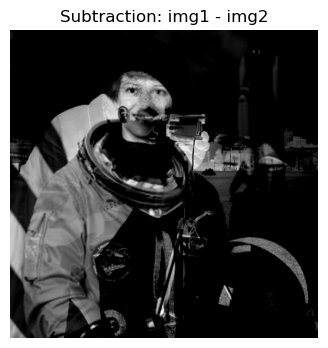

In [9]:
# Cast to a signed/wider type first so we don't wrap around like unsigned subtraction would,
# then clip negative values to 0 before converting back to uint8 for display.
subtraction = im1arr.astype(np.int16) - im2arr.astype(np.int16)
subtraction = np.clip(subtraction, 0, 255).astype(np.uint8)

resultSub = Image.fromarray(subtraction)

plt.figure(figsize=(4, 4))
plt.imshow(resultSub, cmap='gray')
plt.title('Subtraction: img1 - img2')
plt.axis('off')
plt.show()


### 2.2 — Add one image with a constant value of 175 and display it

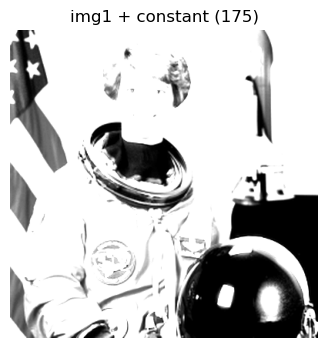

In [8]:
# cv2.add clips (saturates) at 255 instead of wrapping around like plain numpy addition,
# which is what we want for a clean brightness boost.
constant = 175
brightened = cv2.add(im1arr, np.full(im1arr.shape, constant, dtype=np.uint8))

resultConst = Image.fromarray(brightened)

plt.figure(figsize=(4, 4))
plt.imshow(resultConst, cmap='gray')
plt.title(f'img1 + constant ({constant})')
plt.axis('off')
plt.show()


### 2.3 — Apply the set difference operation on two grayscale images

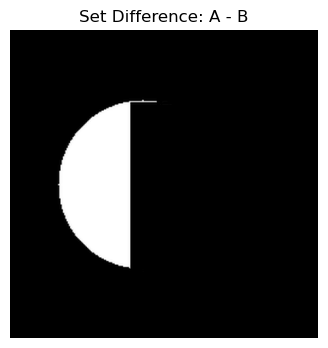

In [10]:
# Set difference A - B = pixels that are "in A" but NOT "in B".
# For images this is commonly done as: A AND (NOT B)
set_difference = cv2.bitwise_and(im3arr, cv2.bitwise_not(im4arr))

resultSetDiff = Image.fromarray(set_difference)

plt.figure(figsize=(4, 4))
plt.imshow(resultSetDiff, cmap='gray')
plt.title('Set Difference: A - B')
plt.axis('off')
plt.show()


### 2.4 — Apply the symmetric difference operation on two grayscale images

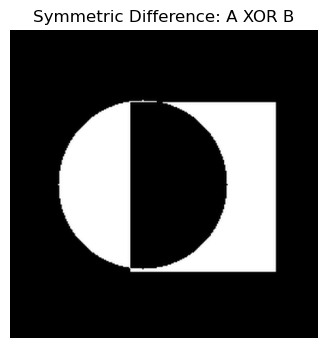

In [11]:
# Symmetric difference = pixels that are in A or B, but NOT in both (i.e. XOR).
symmetric_difference = cv2.bitwise_xor(im3arr, im4arr)

resultSymDiff = Image.fromarray(symmetric_difference)

plt.figure(figsize=(4, 4))
plt.imshow(resultSymDiff, cmap='gray')
plt.title('Symmetric Difference: A XOR B')
plt.axis('off')
plt.show()


### 2.5 — Apply the intersection operation on two grayscale images

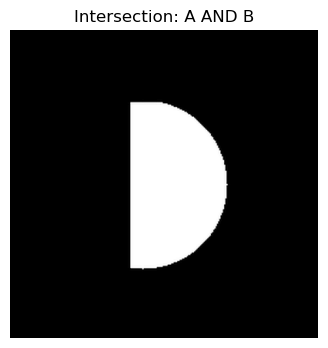

In [12]:
# Intersection = pixels that are "on" in BOTH images -> bitwise AND
intersection = cv2.bitwise_and(im3arr, im4arr)

resultIntersection = Image.fromarray(intersection)

plt.figure(figsize=(4, 4))
plt.imshow(resultIntersection, cmap='gray')
plt.title('Intersection: A AND B')
plt.axis('off')
plt.show()
